In [1]:
# Optional: ensure a compatible Hugging Face stack in this kernel.
# Safe to re-run.

import os
import sys
import subprocess
import importlib.metadata as importlib_metadata

def _version_or_none(pkg_name):
    try:
        return importlib_metadata.version(pkg_name)
    except importlib_metadata.PackageNotFoundError:
        return None

hub_version = _version_or_none("huggingface-hub")
tfm_version = _version_or_none("transformers")

need_install = (
    tfm_version is None
    or hub_version is None
    or hub_version.startswith("1.")
)

if need_install:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "transformers>=4.38,<5",
        "huggingface-hub>=0.19.3,<1.0",
        "safetensors>=0.4.0",
    ])

# Prevent transformers from touching TensorFlow in this environment.
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"


In [2]:
import os
import glob
from pathlib import Path
from typing import Callable, Optional, Sequence, Union

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import SimpleITK as sitk
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from pytorch_ood.detector import Mahalanobis
from pytorch_ood.utils import OODMetrics
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms
from transformers import AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


In [3]:
from pathlib import Path
from typing import Callable, Optional, Sequence, Union
import random

import numpy as np
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F
import nibabel as nib


class MRIMiddleSlicesDataset(Dataset):
    """
    Load MRI .nii / .nii.gz volumes and return only the middle slice
    and its 2 adjacent slices as 2D images.

    Each selected volume contributes exactly 3 samples:
        middle-1, middle, middle+1

    Supports:
    - 3D volumes: (H, W, D) or similar
    - 4D volumes: selects one time/frame first, then extracts slices

    Parameters
    ----------
    root : str or Path
        Root folder containing .nii or .nii.gz files.
    file_paths : optional sequence of paths
        Explicit list of files. If provided, `root` is ignored for scanning.
    slice_axis : int
        Axis along which to slice after reducing to 3D.
    resize_to : optional tuple[int, int]
        If given, resize each 2D slice to (H, W).
    repeat_channels : int
        Output channels: 1 or 3.
    transform : callable, optional
        Applied after tensor conversion.
    return_metadata : bool
        If True, returns a metadata dict.
    label : int
        Label for all samples in this dataset.
    split : str
        One of {"train", "test", "all"}.
    train_ratio : float
        Fraction of volumes assigned to train.
    seed : int
        Random seed for reproducible splitting.
    limit_volumes : int or None
        Optional limit on number of volumes before splitting.
    frame_selector : str | int
        How to reduce 4D -> 3D:
        - "middle": use middle time frame
        - int: use that time index
    """

    def __init__(
        self,
        root: Optional[Union[str, Path]] = None,
        file_paths: Optional[Sequence[Union[str, Path]]] = None,
        slice_axis: int = 2,
        resize_to: Optional[tuple[int, int]] = None,
        repeat_channels: int = 1,
        transform: Optional[Callable] = None,
        return_metadata: bool = False,
        label: int = 0,
        split: str = "all",
        train_ratio: float = 0.7,
        seed: int = 42,
        limit_volumes: Optional[int] = None,
        frame_selector: Union[str, int] = "middle",
    ):
        super().__init__()

        if file_paths is not None:
            files = [Path(p) for p in file_paths]
        else:
            if root is None:
                raise ValueError("Provide either `root` or `file_paths`.")
            root = Path(root)
            files = sorted(
                p for p in root.rglob("*")
                if p.is_file()
                and str(p).endswith((".nii", ".nii.gz"))
                and "_gt.nii" not in p.name
                and "_gt.nii.gz" not in p.name
            )

        if len(files) == 0:
            raise ValueError("No .nii or .nii.gz files found.")

        if repeat_channels not in (1, 3):
            raise ValueError("repeat_channels must be 1 or 3.")

        if split not in {"train", "test", "all"}:
            raise ValueError(f"Unknown split: {split}")

        self.slice_axis = slice_axis
        self.resize_to = resize_to
        self.repeat_channels = repeat_channels
        self.transform = transform
        self.return_metadata = return_metadata
        self.label = label
        self.split = split
        self.train_ratio = train_ratio
        self.seed = seed
        self.frame_selector = frame_selector

        # Split at volume/file level
        rng = random.Random(seed)
        files = list(files)
        rng.shuffle(files)

        if limit_volumes is not None:
            files = files[:limit_volumes]

        n_train = int(round(len(files) * train_ratio))

        if split == "train":
            self.files = files[:n_train]
        elif split == "test":
            self.files = files[n_train:]
        else:
            self.files = files

        if len(self.files) == 0:
            raise ValueError(f"No files left after applying split='{split}'.")

        # Each volume contributes exactly 3 slices
        self.index_map = []
        for file_idx, _ in enumerate(self.files):
            for slice_offset in (-1, 0, 1):
                self.index_map.append((file_idx, slice_offset))

        self.volume_ids = [p.stem.replace(".nii", "") for p in self.files]

    def __len__(self) -> int:
        return len(self.index_map)

    def _load_nifti(self, path: Path) -> np.ndarray:
        vol = nib.load(str(path)).get_fdata()
        return np.asarray(vol, dtype=np.float32)

    def _select_3d_volume(self, vol: np.ndarray) -> tuple[np.ndarray, Optional[int]]:
        """
        Reduce input to 3D.
        Returns:
            vol3d, frame_index
        """
        if vol.ndim == 3:
            return vol, None

        if vol.ndim != 4:
            raise ValueError(f"Expected 3D or 4D volume, got shape {vol.shape}")

        n_frames = vol.shape[-1]

        if self.frame_selector == "middle":
            frame_idx = n_frames // 2
        elif isinstance(self.frame_selector, int):
            frame_idx = int(np.clip(self.frame_selector, 0, n_frames - 1))
        else:
            raise ValueError(f"Unsupported frame_selector: {self.frame_selector}")

        vol3d = vol[..., frame_idx]
        return np.asarray(vol3d, dtype=np.float32), frame_idx

    def _normalize_mri_slice(self, img2d: np.ndarray) -> np.ndarray:
        img = img2d.astype(np.float32)
        mask = img != 0

        if mask.sum() == 0:
            return np.zeros_like(img, dtype=np.float32)

        vals = img[mask]
        lo = np.percentile(vals, 0.5)
        hi = np.percentile(vals, 99.5)

        if hi <= lo:
            out = np.zeros_like(img, dtype=np.float32)
            out[mask] = 1.0
            return out

        img = np.clip(img, lo, hi)
        img = (img - lo) / (hi - lo)
        img[~mask] = 0.0
        return img.astype(np.float32)

    def _extract_slice(self, vol3d: np.ndarray, slice_offset: int) -> tuple[np.ndarray, int]:
        n_slices = vol3d.shape[self.slice_axis]
        mid = n_slices // 2
        idx = int(np.clip(mid + slice_offset, 0, n_slices - 1))

        img2d = np.take(vol3d, indices=idx, axis=self.slice_axis)
        return np.asarray(img2d, dtype=np.float32), idx

    def _to_tensor(self, img2d: np.ndarray) -> torch.Tensor:
        x = torch.from_numpy(img2d).float().unsqueeze(0)  # [1, H, W]

        if self.resize_to is not None:
            x = F.interpolate(
                x.unsqueeze(0),
                size=self.resize_to,
                mode="bilinear",
                align_corners=False,
            ).squeeze(0)

        if self.repeat_channels == 3:
            x = x.repeat(3, 1, 1)

        return x

    def __getitem__(self, idx: int):
        file_idx, slice_offset = self.index_map[idx]
        path = self.files[file_idx]

        vol = self._load_nifti(path)
        vol3d, frame_idx = self._select_3d_volume(vol)

        img2d, slice_idx = self._extract_slice(vol3d, slice_offset)
        img2d = self._normalize_mri_slice(img2d)
        x = self._to_tensor(img2d)

        if self.transform is not None:
            x = self.transform(x)

        if self.return_metadata:
            meta = {
                "path": str(path),
                "file_name": path.name,
                "slice_offset": slice_offset,
                "slice_index": slice_idx,
                "original_shape": tuple(vol.shape),
                "used_shape": tuple(vol3d.shape),
            }
            return x, self.label, meta

        return x,self.label

In [4]:
# DINOv2-base is the closest Hugging Face DINOv2 size to a ViT-B / medSAM-vit_b backbone.
DINO_MODEL_NAME = "facebook/dinov2-base"
DINO_IMAGE_SIZE = 224
DINO_PATCH_SIZE = 14
DINO_EMBED_DIM = 768

dinov2 = AutoModel.from_pretrained(DINO_MODEL_NAME).to(device).eval()
print("Loaded:", DINO_MODEL_NAME)

DINO_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
DINO_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def preprocess_for_dinov2(x: torch.Tensor) -> torch.Tensor:
    """
    x: [B, C, H, W]
    - accepts float tensors in [0, 1] or image-like tensors in [0, 255]
    - converts grayscale to 3 channels
    - resizes to 224x224
    - normalizes with ImageNet mean/std as expected by DINOv2
    """
    if not torch.is_floating_point(x):
        x = x.float()

    if x.max() > 1.0:
        x = x / 255.0

    if x.shape[1] == 1:
        x = x.repeat(1, 3, 1, 1)
    elif x.shape[1] > 3:
        x = x[:, :3, :, :]

    x = F.interpolate(
        x,
        size=(DINO_IMAGE_SIZE, DINO_IMAGE_SIZE),
        mode="bicubic",
        align_corners=False,
    )

    mean = DINO_MEAN.to(device=x.device, dtype=x.dtype)
    std = DINO_STD.to(device=x.device, dtype=x.dtype)
    x = (x - mean) / std
    return x

@torch.no_grad()
def extract_dinov2_features(x: torch.Tensor):
    """
    Returns:
      cls_features:   [B, 768]
      patch_features: [B, 768, 16, 16]
      patch_tokens:   [B, 256, 768]
    """
    x = preprocess_for_dinov2(x).to(device)
    outputs = dinov2(pixel_values=x)
    hidden = outputs.last_hidden_state
    cls_features = hidden[:, 0]
    patch_tokens = hidden[:, 1:]

    grid = DINO_IMAGE_SIZE // DINO_PATCH_SIZE
    patch_features = patch_tokens.transpose(1, 2).reshape(-1, DINO_EMBED_DIM, grid, grid)
    return cls_features, patch_features, patch_tokens

@torch.no_grad()
def get_embedding(batch_images: torch.Tensor) -> torch.Tensor:
    cls_features, _, _ = extract_dinov2_features(batch_images)
    return cls_features


/home/jovyan/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded: facebook/dinov2-base


In [5]:
datasets_path = "../datasets/"
prep_datasets = "/prep_datasets"
ID_path = datasets_path + prep_datasets + "/MnM_splits/vendor_split_ed_es/Philips"
OOD_path = datasets_path + prep_datasets + "/MnM_splits/vendor_split_ed_es/Siemens"

# Use 224x224 because DINOv2-base is trained around this input size.
id_train_dataset = MRIMiddleSlicesDataset(
    root=ID_path,
    resize_to=(224, 224),
    repeat_channels=3,
    label=0,
    split="train",
    seed=42,
    train_ratio=0.7,
    return_metadata=False,
)


id_val_dataset = MRIMiddleSlicesDataset(
    root=ID_path,
    resize_to=(224, 224),
    repeat_channels=3,
    label=0,
    split="test",
    seed=42,
    train_ratio=0.7,
    return_metadata=False,
)

ood_dataset = MRIMiddleSlicesDataset(
    root=OOD_path,
    resize_to=(224, 224),
    repeat_channels=3,
    split="all",
    seed=42,
    label=-1,
    return_metadata=False,
)

id_train_loader = DataLoader(id_train_dataset, batch_size=4, shuffle=True, num_workers=0)
id_val_loader = DataLoader(id_val_dataset, batch_size=4, shuffle=True, num_workers=0)

ood_loader = DataLoader(ood_dataset, batch_size=4, shuffle=True, num_workers=0)

print("ID train samples:", len(id_train_dataset))
print("ID val samples:", len(id_val_dataset))
print("OOD samples:", len(ood_dataset))


ID train samples: 525
ID val samples: 225
OOD samples: 570


In [7]:
imgs, labels= next(iter(id_val_loader))
imgs_ood, labels_ood = next(iter(ood_loader))

print("ID batch:", imgs.shape, labels.shape)
print("OOD batch:", imgs_ood.shape, labels_ood.shape)
print("ID value range:", float(imgs.min()), float(imgs.max()))
print("OOD value range:", float(imgs_ood.min()), float(imgs_ood.max()))


ID batch: torch.Size([4, 3, 224, 224]) torch.Size([4])
OOD batch: torch.Size([4, 3, 224, 224]) torch.Size([4])
ID value range: 0.0 1.0
OOD value range: 0.0 1.0


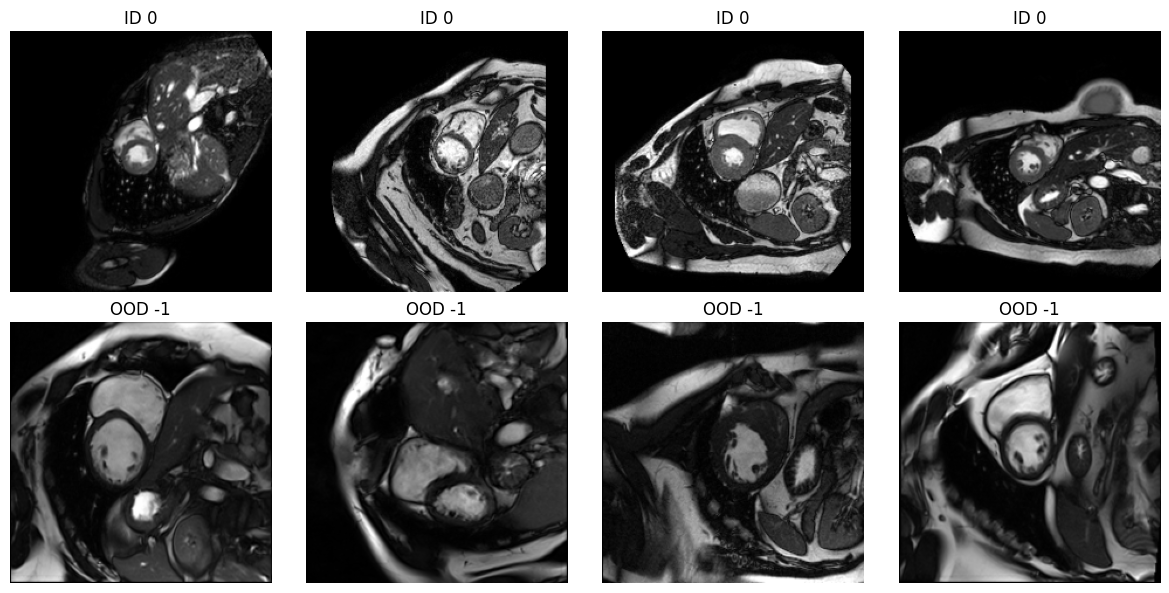

In [8]:
imgs, labels = next(iter(id_train_loader))
imgs_ood, labels_ood= next(iter(ood_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    img = imgs[i].permute(1, 2, 0).cpu().numpy()
    img_ood = imgs_ood[i].permute(1, 2, 0).cpu().numpy()

    axes[0, i].imshow(img)
    axes[0, i].set_title(f"ID {int(labels[i])}")
    axes[0, i].axis("off")

    axes[1, i].imshow(img_ood)
    axes[1, i].set_title(f"OOD {int(labels_ood[i])}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


In [9]:
# Stage 1: extract DINOv2 embeddings from the ID data and fit Mahalanobis

feats_list = []
labels_list = []

dinov2.eval()
with torch.no_grad():
    for imgs, y in id_train_loader:
        imgs = imgs.to(device)
        y = y.to(device)

        z = get_embedding(imgs)   # [B, 768] CLS token
        feats_list.append(z)
        labels_list.append(y)

Z_id = torch.cat(feats_list, dim=0)
Y_id = torch.cat(labels_list, dim=0)

print("Z_id:", Z_id.shape)
print("Y_id:", Y_id.shape, "unique labels:", torch.unique(Y_id))

detector = Mahalanobis(model=None)
detector.fit_features(Z_id, Y_id)


No device given. Will use 'cpu'.


Z_id: torch.Size([525, 768])
Y_id: torch.Size([525]) unique labels: tensor([0])


In [10]:
# Predict on OOD dataset

feats_list_id_val = []
feats_list_ood=[]
with torch.no_grad():
    
    for imgs, _ in id_val_loader:
        imgs = imgs.to(device)
        z = get_embedding(imgs)
        feats_list_id_val.append(z)
    
    for imgs, _ in ood_loader:
        imgs = imgs.to(device)
        z = get_embedding(imgs)
        feats_list_ood.append(z)

Z_id_val= torch.cat(feats_list_id_val, dim=0)     
Z_ood = torch.cat(feats_list_ood, dim=0)

scores_id_val = detector.predict_features(Z_id_val)
scores_ood = detector.predict_features(Z_ood)

print("Z_ood:", Z_ood.shape)
print("scores_id:", scores_id_val.shape)
print("scores_ood:", scores_ood.shape)


Z_ood: torch.Size([570, 768])
scores_id: torch.Size([225])
scores_ood: torch.Size([570])


In [11]:
# Evaluate OOD metrics


img_scores = torch.cat([scores_id_val, scores_ood], dim=0)
img_labels = torch.cat([
    torch.zeros(len(scores_id_val), dtype=torch.long),
    -torch.ones(len(scores_ood), dtype=torch.long),
], dim=0)

metrics = OODMetrics()
metrics.update(img_scores, img_labels)
img_result = metrics.compute()

print("Image-level metrics:")
print(img_result)


Image-level metrics:
{'AUROC': 0.5466081500053406, 'AUTC': 0.4848635196685791, 'AUPR-IN': 0.47933483123779297, 'AUPR-OUT': 0.819367527961731, 'FPR95TPR': 1.0}


In [12]:
print("ID stats:")
print("mean:", scores_id_val.mean().item())
print("std:", scores_id_val.std().item())
print("min:", scores_id_val.min().item())
print("max:", scores_id_val.max().item())

ID stats:
mean: 10326.798828125
std: 86872.6171875
min: -209525.015625
max: 389469.375


In [13]:
print("OOD stats:")
print("mean:", scores_ood.mean().item())
print("std:", scores_ood.std().item())
print("min:", scores_ood.min().item())
print("max:", scores_ood.max().item())
print("median", scores_ood.median().item())

OOD stats:
mean: 74116.171875
std: 249984.046875
min: -664373.5
max: 1444117.75
median 47129.1796875


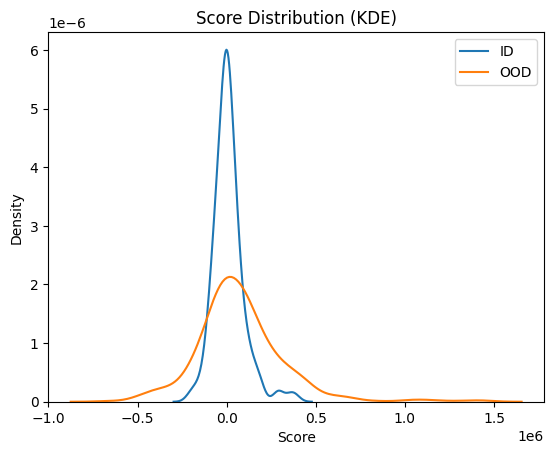

In [14]:

import seaborn as sns
import matplotlib.pyplot as plt

scores_id_np = scores_id_val.detach().cpu().numpy()
scores_ood_np = scores_ood.detach().cpu().numpy()

sns.kdeplot(scores_id_np, label="ID", fill=False)
sns.kdeplot(scores_ood_np, label="OOD", fill=False)

#plt.xlim(-10000, -9000)

plt.title("Score Distribution (KDE)")
plt.xlabel("Score")
plt.ylabel("Density")
plt.legend()

plt.show()

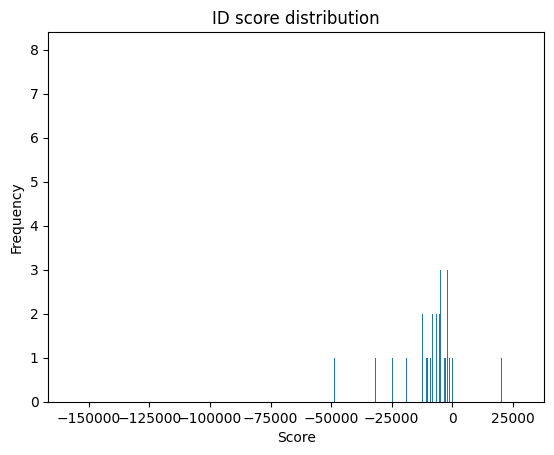

In [138]:
plt.hist(scores_ood.detach().cpu().numpy(), bins=5000)
plt.title("ID score distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()